In [42]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.colors import to_rgba, LinearSegmentedColormap
import ot
from itertools import combinations
from scipy.stats import norm, multivariate_normal
from scipy.linalg import sqrtm, inv

# ── load Manhattan background ────────────────────────────────────
data = np.load("manhattan.npz")
Imap = data["Imap"]

# BG     = '#F7F4EF'   # warm off-white background
BG     = '#FFFFFF'   # white background

plt.rcParams.update({
    'figure.facecolor': BG,
    'axes.facecolor':   BG,
    'font.family':      'serif',
    'mathtext.fontset': 'cm',
    'axes.spines.top':  False,
    'axes.spines.right':False,
    'axes.grid':        False,
})

---
# Monge vs Kantorovich — Manhattan Bakeries & Cafés

Synthetic bakery/café positions overlaid on the Manhattan map, with weights chosen so that:
- A valid deterministic **Monge map** exists (one arrow per bakery, marginals satisfied).
- The **Kantorovich coupling** is strictly cheaper by splitting mass.

**Weight design.**  
4 bakeries with weights $[50, 30, 50, 30]$, 2 cafés with weights $[80, 80]$ (equal totals).  
The only valid Monge partitions pair each café with exactly two bakeries whose weights sum to 80 ($50+30$). The optimal such pairing assigns the top pair to C0 and the bottom pair to C1.  
The Kantorovich plan breaks this constraint and reroutes part of B0's supply to C1 instead, achieving a strictly lower total squared-distance cost.

Dependencies: `numpy`, `scipy`, `matplotlib`, `POT`

In [43]:
# ── synthetic positions (pixel coordinates) ──────────────────────
bakery_pos = np.array([
    [400., 300.],   # B0  top-left
    [500., 330.],   # B1  top-right
    [200., 340.],   # B2  bot-left
    [600., 300.],   # B3  bot-right
])
cafe_pos = np.array([
    [500., 200.],   # C0  top-right
    [300., 475.],   # C1  bot-left
])
bakery_prod = np.array([60., 20., 50., 30.])   # sum = 160
cafe_prod   = np.array([80., 80.])             # sum = 160

In [44]:

# ── cost matrix (squared Euclidean) ──────────────────────────────
M = ot.dist(bakery_pos, cafe_pos, metric='sqeuclidean')

# ══════════════════════════════════════════════════════════════════
# KANTOROVICH  —  standard EMD
# ══════════════════════════════════════════════════════════════════
G_kanto    = ot.emd(bakery_prod, cafe_prod, M)
kanto_cost = (G_kanto * M).sum()

# ══════════════════════════════════════════════════════════════════
# MONGE  —  optimal deterministic assignment
#
# A valid Monge map assigns each bakery to exactly one café such that
# total weight sent to each café equals its demand.
# With weights [50,30,50,30] → [80,80] the only feasible groupings
# pair one weight-50 and one weight-30 bakery per café.
# We enumerate all valid pairings and take the minimum-cost one.
# ══════════════════════════════════════════════════════════════════
best_monge_cost = np.inf
best_assign     = None

for g0 in combinations(range(4), 2):
    g1 = [i for i in range(4) if i not in g0]
    if not (abs(bakery_prod[list(g0)].sum() - cafe_prod[0]) < 1e-6 and
            abs(bakery_prod[g1].sum()        - cafe_prod[1]) < 1e-6):
        continue
    for cafe_order in [(0, 1), (1, 0)]:
        assign = [None] * 4
        for i in g0: assign[i] = cafe_order[0]
        for i in g1: assign[i] = cafe_order[1]
        cost = sum(bakery_prod[i] * M[i, assign[i]] for i in range(4))
        if cost < best_monge_cost:
            best_monge_cost = cost
            best_assign     = assign[:]

G_monge = np.zeros_like(G_kanto)
for i, j in enumerate(best_assign):
    G_monge[i, j] = bakery_prod[i]

# ── sanity checks ─────────────────────────────────────────────────
assert np.allclose(G_monge.sum(axis=1), bakery_prod), "Bakery marginal violated"
assert np.allclose(G_monge.sum(axis=0), cafe_prod),   "Café marginal violated"
assert all((G_monge[i] > 1e-9).sum() == 1 for i in range(4)), "Monge map not deterministic"
assert best_monge_cost > kanto_cost + 1,               "Monge cost should be strictly higher"

print(f"Monge cost  : {best_monge_cost:,.0f}")
print(f"Kanto cost  : {kanto_cost:,.0f}")
print(f"Difference  : {best_monge_cost - kanto_cost:,.0f}  "
      f"({100*(best_monge_cost/kanto_cost - 1):.1f}% higher)")
print(f"Monge assign: {best_assign}  (bakery i → café j)")
print(f"Kanto splits: B0 → {G_kanto[0,0]:.0f} to C0, {G_kanto[0,1]:.0f} to C1")

Monge cost  : 6,568,000
Kanto cost  : 4,168,000
Difference  : 2,400,000  (57.6% higher)
Monge assign: [0, 0, 1, 1]  (bakery i → café j)
Kanto splits: B0 → 30 to C0, 30 to C1


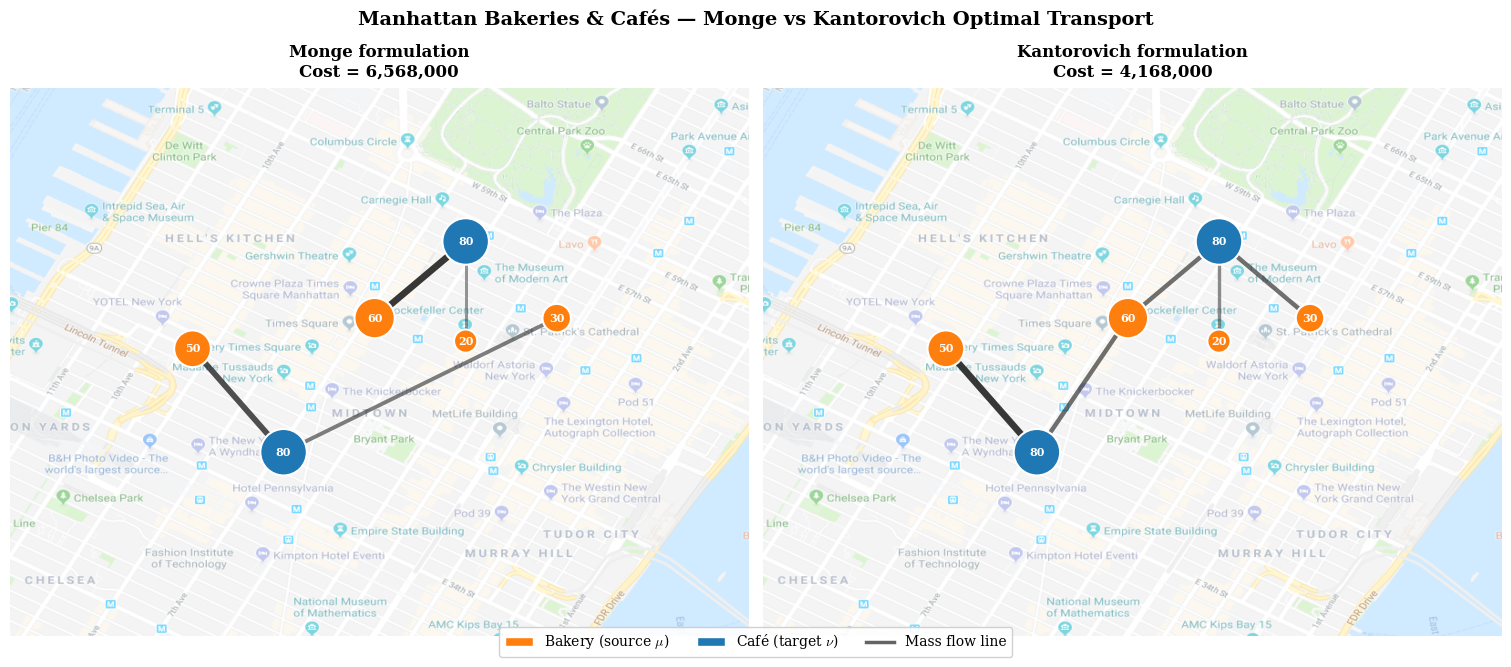

In [50]:
# ── style constants ───────────────────────────────────────────────
C_BAKERY = '#ff7f0e'   # burnt orange — source
C_CAFE   = '#1f77b4'   # steel blue   — target
C_LINE   = '#222222'

S_SCALE  = 14          # marker area = weight × S_SCALE


def draw_panel(ax, G, title, cost):
    ax.imshow(Imap, interpolation='bilinear', alpha=0.55, aspect='auto')

    g_max = G[G > 1e-6].max()
    for i in range(len(bakery_prod)):
        for j in range(len(cafe_prod)):
            m = G[i, j]
            if m < 1e-6:
                continue
            frac = m / g_max
            ax.plot(
                [bakery_pos[i, 0], cafe_pos[j, 0]],
                [bakery_pos[i, 1], cafe_pos[j, 1]],
                color=C_LINE, lw=0.8 + 4.0 * frac,
                alpha=0.25 + 0.65 * frac,
                solid_capstyle='round', zorder=2,
            )

    ax.scatter(cafe_pos[:, 0], cafe_pos[:, 1],
               s=cafe_prod * S_SCALE, c=C_CAFE, marker='o',
               zorder=4, edgecolors='white', linewidths=1.5)
    ax.scatter(bakery_pos[:, 0], bakery_pos[:, 1],
               s=bakery_prod * S_SCALE, c=C_BAKERY, marker='o',
               zorder=4, edgecolors='white', linewidths=1.5)

    for p, w in zip(bakery_pos, bakery_prod):
        ax.text(p[0], p[1], f'{int(w)}', ha='center', va='center',
                fontsize=8, color='white', fontweight='bold', zorder=5)
    for p, w in zip(cafe_pos, cafe_prod):
        ax.text(p[0], p[1], f'{int(w)}', ha='center', va='center',
                fontsize=8, color='white', fontweight='bold', zorder=5)

    ax.set_title(f'{title}\nCost = {cost:,.0f}',
                 fontsize=12, fontweight='bold', pad=8)
    ax.axis('off')


fig, axes = plt.subplots(1, 2, figsize=(15, 6),
                         facecolor='white', constrained_layout=True)
for ax in axes:
    ax.set_facecolor('white')

draw_panel(axes[0], G_monge,
           'Monge formulation',
           best_monge_cost)
draw_panel(axes[1], G_kanto,
           'Kantorovich formulation',
           kanto_cost)

legend_elements = [
    mpatches.Patch(facecolor=C_BAKERY, edgecolor='white',
                   label='Bakery (source $\\mu$)'),
    mpatches.Patch(facecolor=C_CAFE,   edgecolor='white',
                   label='Café (target $\\nu$)'),
    plt.Line2D([0], [0], color=C_LINE, lw=2.5, alpha=0.7,
               label='Mass flow line'),
]
fig.legend(handles=legend_elements, loc='lower center', ncol=3,
           fontsize=10, framealpha=0.9, bbox_to_anchor=(0.5, -0.04))

fig.suptitle('Manhattan Bakeries & Cafés — Monge vs Kantorovich Optimal Transport',
             fontsize=14, fontweight='bold', y=1.05)

plt.savefig('fig_monge_vs_kantorovich_manhattan.pdf',
            bbox_inches='tight', facecolor='white')
plt.savefig('fig_monge_vs_kantorovich_manhattan.png',
            dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

---
## Displacement interpolation vs linear mixture

**Setup:**
- Source: $\mu_0 = \mathcal{N}(-2,\, 1.5^2)$  (left, higher variance)
- Target: $\mu_1 = \mathcal{N}(+2,\, 0.6^2)$  (right, lower variance)

**Displacement interpolation** (Benamou-Brenier / Definition 2.22):  
Since both measures are Gaussian, the Brenier map is
$T(x) = \nabla\phi(x) = \frac{\sigma_1}{\sigma_0}(x - m_0) + m_1$,
a linear map. The geodesic is
$$\mu_t = \mathcal{N}\!\bigl(m_0 + t(m_1 - m_0),\; \bigl((1-t)\sigma_0 + t\sigma_1\bigr)^2\bigr).$$

**Linear mixture** (not a geodesic):
$\rho_t = (1-t)\mu_0 + t\mu_1$,
which is a bi-modal density for $t\in(0,1)$ — the mass does not 'move', it simply fades.

The key visual distinction: the geodesic always has a single mode that travels smoothly from left to right while the standard deviation interpolates linearly; the mixture shows two humps for intermediate $t$.

In [51]:
# ── shared palette ──────────────────────────────────────────────
C_SRC  = '#1f77b4'   # blue  – source
C_TGT  = '#ff7f0e'   # red   – target
# '#1f77b4'
# C_TGT = '#ff7f0e'
C_LIN  = '#B7791F'   # amber – linear mixture

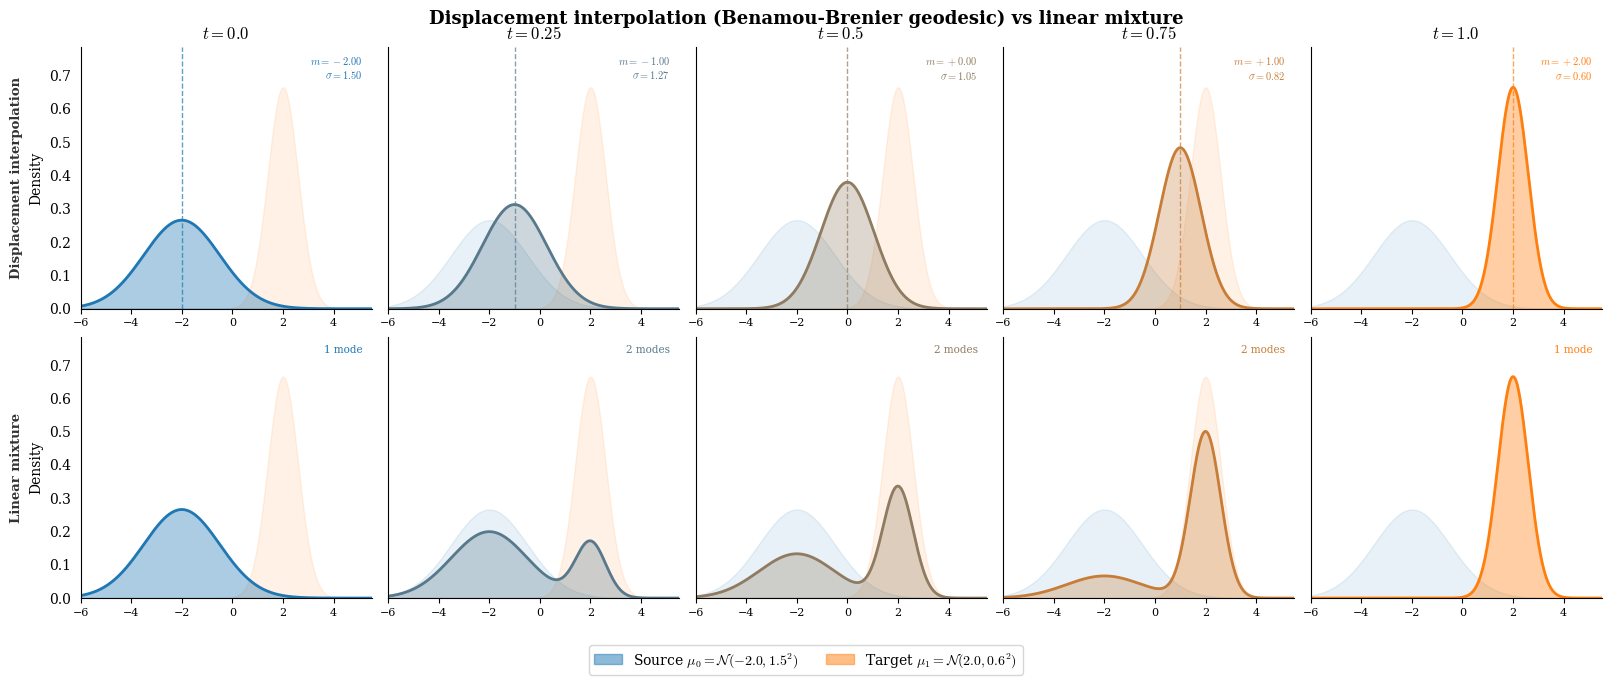

In [52]:
# ── Parameters ───────────────────────────────────────────────────
m0, s0 = -2.0, 1.5   # source
m1, s1 =  2.0, 0.6   # target

ts = [0.0, 0.25, 0.50, 0.75, 1.0]

x = np.linspace(-6, 5.5, 1000)

def geodesic_density(t, x):
    """Density of the displacement interpolation at time t.
    For Gaussians: N( m0 + t(m1-m0), ((1-t)s0 + t*s1)^2 )."""
    mt = m0 + t * (m1 - m0)
    st = (1 - t) * s0 + t * s1
    return norm.pdf(x, mt, st), mt, st

def linear_density(t, x):
    """Density of (1-t)*mu0 + t*mu1 at time t."""
    return (1 - t) * norm.pdf(x, m0, s0) + t * norm.pdf(x, m1, s1)

# ── Colour ramp across time ───────────────────────────────────────
src_rgba = np.array(to_rgba(C_SRC))
tgt_rgba = np.array(to_rgba(C_TGT))
def blend(t): return tuple((1-t)*src_rgba + t*tgt_rgba)

# ── Figure ────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    2, 5, figsize=(16, 6),
    facecolor=BG,
    sharey='row',
    constrained_layout=True,
)

row_titles = [
    'Displacement interpolation',
    'Linear mixture'
]

y_max_geo = max(
    geodesic_density(t, x)[0].max() for t in ts
) * 1.18
y_max_lin = max(
    linear_density(t, x).max() for t in ts
) * 1.18

for col, t in enumerate(ts):
    col_color = blend(t)

    # ── Row 0: displacement interpolation ──────────────────
    ax = axes[0, col]
    ax.set_facecolor(BG)
    pdf_geo, mt, st = geodesic_density(t, x)

    # Source and target as light reference fills
    ax.fill_between(x, norm.pdf(x, m0, s0), alpha=0.10, color=C_SRC)
    ax.fill_between(x, norm.pdf(x, m1, s1), alpha=0.10, color=C_TGT)
    # Interpolated density
    ax.fill_between(x, pdf_geo, alpha=0.30, color=col_color)
    ax.plot(x, pdf_geo, lw=2.0, color=col_color)
    # Vertical line at mode
    ax.axvline(mt, lw=1.0, ls='--', color=col_color, alpha=0.7)

    ax.set_xlim(x[0], x[-1])
    ax.set_ylim(0, y_max_geo)
    ax.set_title(f'$t = {t}$', fontsize=12)
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(left=False, labelleft=(col == 0))
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
    if col == 0:
        ax.set_ylabel('Density', fontsize=10)

    # Annotation: mean ± std
    ax.text(0.97, 0.97,
            f'$m={mt:+.2f}$\n$\\sigma={st:.2f}$',
            transform=ax.transAxes, fontsize=7.5,
            ha='right', va='top', color=col_color,
            bbox=dict(fc=BG, ec='none', pad=1))

    # ── Row 1: linear mixture ───────────────────────────────
    ax = axes[1, col]
    ax.set_facecolor(BG)
    pdf_lin = linear_density(t, x)

    ax.fill_between(x, norm.pdf(x, m0, s0), alpha=0.10, color=C_SRC)
    ax.fill_between(x, norm.pdf(x, m1, s1), alpha=0.10, color=C_TGT)
    ax.fill_between(x, pdf_lin, alpha=0.30, color=col_color)
    ax.plot(x, pdf_lin, lw=2.0, color=col_color)

    ax.set_xlim(x[0], x[-1])
    ax.set_ylim(0, y_max_lin)
    ax.tick_params(axis='x', labelsize=8)
    ax.tick_params(left=False, labelleft=(col == 0))
    for sp in ['top', 'right']:
        ax.spines[sp].set_visible(False)
    if col == 0:
        ax.set_ylabel('Density', fontsize=10)

    # Number of modes (rough: count local maxima)
    grad = np.diff(np.sign(np.diff(pdf_lin)))
    n_modes = int((grad < 0).sum())
    ax.text(0.97, 0.97,
            f'{n_modes} mode{"s" if n_modes != 1 else ""}',
            transform=ax.transAxes, fontsize=7.5,
            ha='right', va='top', color=col_color,
            bbox=dict(fc=BG, ec='none', pad=1))

# Row labels on the left
for row, title in enumerate(row_titles):
    axes[row, 0].annotate(
        title, xy=(-0.22, 0.5), xycoords='axes fraction',
        fontsize=9.5, rotation=90, va='center', ha='center',
        fontweight='bold', color='#333',
    )

# Legend patches
src_patch = mpatches.Patch(color=C_SRC, alpha=0.5,
                           label=f'Source $\\mu_0 = \\mathcal{{N}}({m0},{s0}^2)$')
tgt_patch = mpatches.Patch(color=C_TGT, alpha=0.5,
                           label=f'Target $\\mu_1 = \\mathcal{{N}}({m1},{s1}^2)$')
fig.legend(
    handles=[src_patch, tgt_patch],
    loc='lower center', ncol=2, fontsize=10,
    framealpha=0.8, bbox_to_anchor=(0.5, -0.1),
)

fig.suptitle(
    'Displacement interpolation (Benamou-Brenier geodesic) vs linear mixture',
    fontsize=13, fontweight='bold', y=1.02,
)

plt.savefig('fig_interpolation_comparison.pdf', bbox_inches='tight', facecolor=BG)
plt.savefig('fig_interpolation_comparison.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()

In [53]:
# ── Parameters & Colors ──────────────────────────────────────────
C_SRC = '#1f77b4'
C_TGT = '#ff7f0e'
BG = '#ffffff'

m0 = np.array([-4.0, -1.0])
S0 = np.array([[ 1.0, 0.9], 
               [0.9,  1.0]])  # Horizontally stretched

m1 = np.array([ 4.0,  1.0])
S1 = np.array([[ 1.0, -0.9], 
               [-0.9,  1.0]])  # Diagonally stretched

# Reference measure for generalised geodesic (vertically stretched)
m_ref = np.array([0.0, 0.0])
S_ref = np.array([[ 0.1,  0.0], 
                  [ 0.0,  10.0]])

ts = [0.0, 0.25, 0.50, 0.75, 1.0]

# 2D Grid for plotting
x, y = np.mgrid[-7:7:150j, -4:4:150j]
pos = np.dstack((x, y))

# ── Optimal Transport Math ────────────────────────────────────────
def sym_sqrt(A):
    """Symmetric square root of a positive definite matrix."""
    S, V = np.linalg.eigh(A)
    return V @ np.diag(np.sqrt(np.maximum(S, 0))) @ V.T

def ot_map(S_A, S_B):
    """Computes the optimal transport map T from N(0, S_A) to N(0, S_B)."""
    inv_sqrt_A = sym_sqrt(inv(S_A))
    sqrt_A = sym_sqrt(S_A)
    return inv_sqrt_A @ sym_sqrt(sqrt_A @ S_B @ sqrt_A) @ inv_sqrt_A

# Precompute the standard map T_{0->1}
T_01 = ot_map(S0, S1)

# Precompute maps from reference to source and target
T_ref_0 = ot_map(S_ref, S0)
T_ref_1 = ot_map(S_ref, S1)

def geodesic_params(t):
    """Parameters for standard displacement interpolation."""
    mt = (1 - t) * m0 + t * m1
    Tt = (1 - t) * np.eye(2) + t * T_01
    St = Tt @ S0 @ Tt.T
    return mt, St

def linear_density(t, pos):
    """Density for linear mixture."""
    pdf0 = multivariate_normal(m0, S0).pdf(pos)
    pdf1 = multivariate_normal(m1, S1).pdf(pos)
    return (1 - t) * pdf0 + t * pdf1

def generalised_params(t):
    """Parameters for generalised geodesic via reference sigma."""
    mt = (1 - t) * m0 + t * m1
    At = (1 - t) * T_ref_0 + t * T_ref_1
    St = At @ S_ref @ At.T
    return mt, St

# ── Utilities ─────────────────────────────────────────────────────
src_rgba = np.array(to_rgba(C_SRC))
tgt_rgba = np.array(to_rgba(C_TGT))
def blend(t): return tuple((1-t)*src_rgba + t*tgt_rgba)

pdf_src = multivariate_normal(m0, S0).pdf(pos)
pdf_tgt = multivariate_normal(m1, S1).pdf(pos)

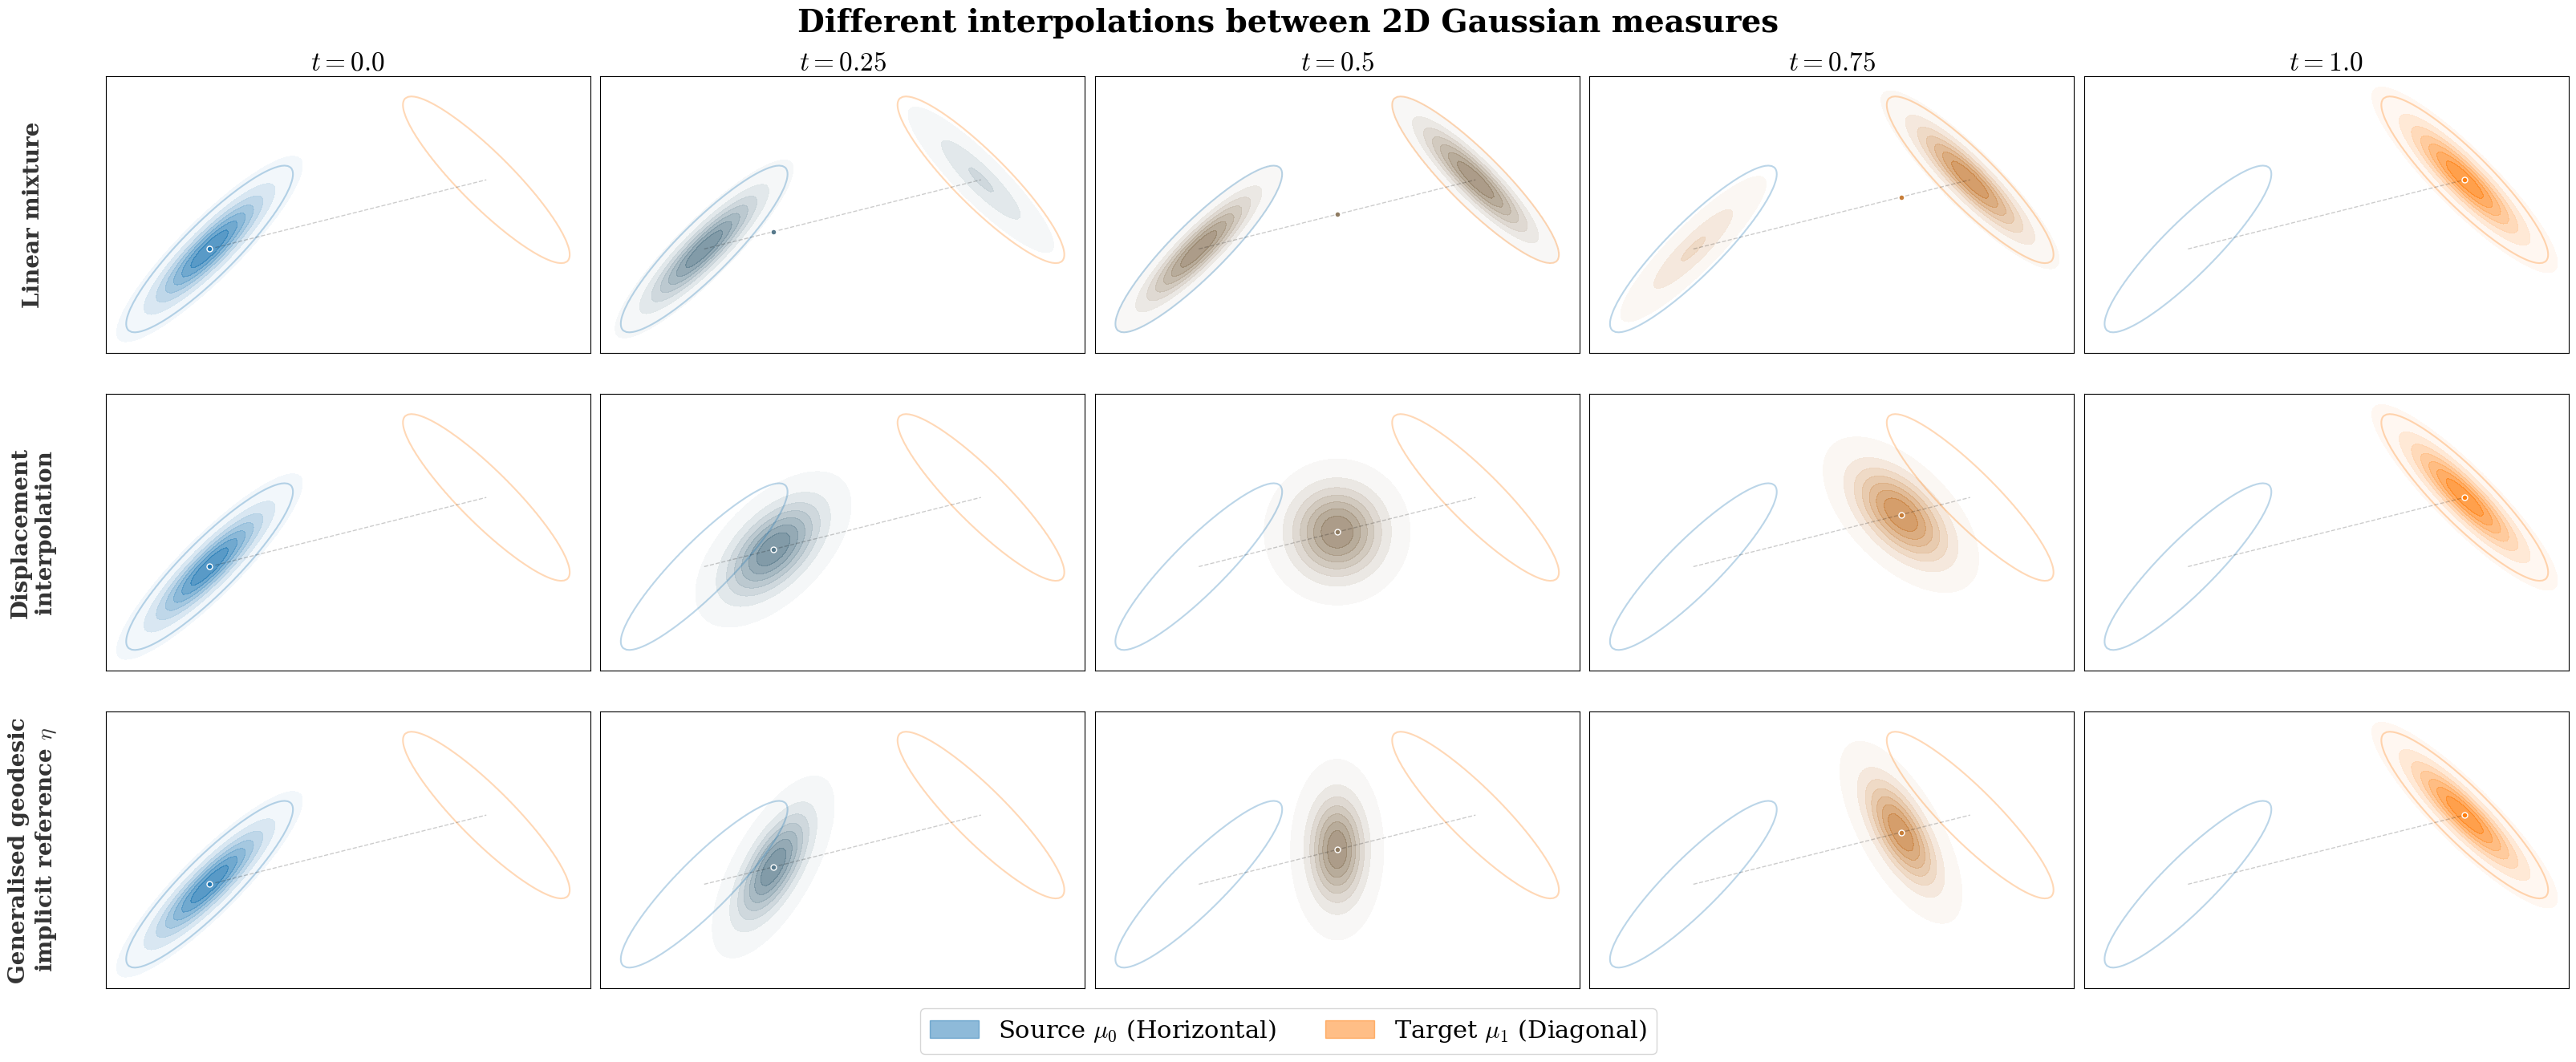

In [54]:
# ── Figure ────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    3, 5, figsize=(32, 12),
    facecolor=BG, sharex=True, sharey=True,
    constrained_layout=True,
)

row_titles = [
    'Linear mixture',
    'Displacement\ninterpolation',
    'Generalised geodesic\nimplicit reference $\\eta$',
]

for col, t in enumerate(ts):
    col_color = blend(t)
    cmap = LinearSegmentedColormap.from_list('custom', [BG, col_color])
    
    # Pre-calculate PDFs for this timestep
    m_geo, S_geo = geodesic_params(t)
    pdf_geo = multivariate_normal(m_geo, S_geo).pdf(pos)
    
    pdf_lin = linear_density(t, pos)
    
    m_gen, S_gen = generalised_params(t)
    pdf_gen = multivariate_normal(m_gen, S_gen).pdf(pos)

    pdfs = [pdf_lin, pdf_geo, pdf_gen]
    
    for row in range(3):
        ax = axes[row, col]
        ax.set_facecolor(BG)
        ax.set_aspect('equal')
        
        # Draw light source/target outlines as reference
        ax.contour(x, y, pdf_src, levels=[0.02], colors=[C_SRC], alpha=0.3, linewidths=1.5)
        ax.contour(x, y, pdf_tgt, levels=[0.02], colors=[C_TGT], alpha=0.3, linewidths=1.5)
        
        # Plot the interpolated density
        ax.contourf(x, y, pdfs[row], levels=np.linspace(0.01, pdfs[row].max(), 8), cmap=cmap, alpha=0.8)
        
        # Plot the path of the mean
        ax.plot([m0[0], m1[0]], [m0[1], m1[1]], 'k--', alpha=0.2, lw=1)
        
        # Indicate the current mean location

        mt = m_geo if row == 0 else m_gen
        ax.plot(mt[0], mt[1], 'o', color=col_color, markersize=5, mec='w', mew=1)
            
        if row == 0:
            ax.set_title(f'$t = {t}$', fontsize=24)
            
        ax.set_xticks([])
        ax.set_yticks([])
        for sp in ['top', 'right', 'left', 'bottom']:
            ax.spines[sp].set_visible(True)

# Row labels
for row, title in enumerate(row_titles):
    axes[row, 0].annotate(
        title, xy=(-0.15, 0.5), xycoords='axes fraction', 
        fontsize=20, rotation=90, va='center', ha='center',
        fontweight='bold', color='#333',
    )

# Legend patches
src_patch = mpatches.Patch(color=C_SRC, alpha=0.5, label='Source $\\mu_0$ (Horizontal)')
tgt_patch = mpatches.Patch(color=C_TGT, alpha=0.5, label='Target $\\mu_1$ (Diagonal)')
ref_patch = mpatches.Patch(color='#888888', alpha=0.5, label='Implicit Reference $\\eta$')

fig.legend(
    handles=[src_patch, tgt_patch],
    loc='lower center', ncol=3, fontsize=22,
    framealpha=0.8, bbox_to_anchor=(0.5, -0.06),
)

fig.suptitle(
    'Different interpolations between 2D Gaussian measures',
    fontsize=28, fontweight='bold', y=1.04,
)

plt.savefig('fig_2d_interpolation_comparison.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.savefig('fig_2d_interpolation_comparison.pdf', bbox_inches='tight', facecolor=BG)
plt.show()